<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/RBF_kernel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Text(0.5, 1.0, 'Gaussian RBF(x1)_Similarity Distribution of Gaussian RBF Kernel for Two Landmarks')

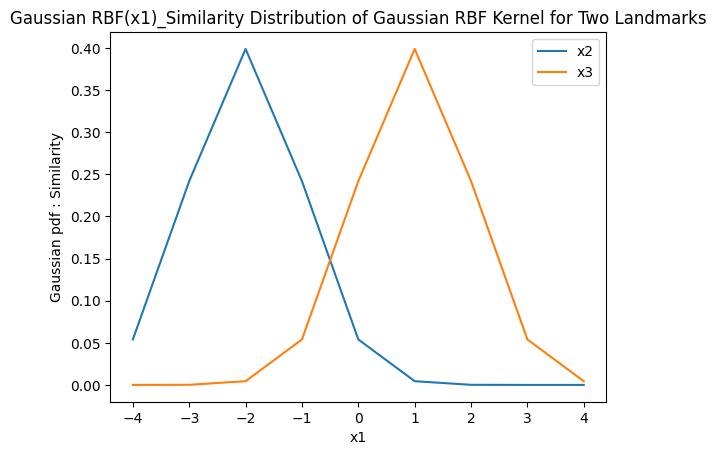

In [6]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

x1 = np.arange(-4, 5, 1)
x2 = stats.norm.pdf(x1, -2, 1) # 평균 -2, 표준편차 1인 정규분포 PDF
x3 = stats.norm.pdf(x1, 1, 1)  # 평균 1, 표준편차 1인 정규분포 PDF

plt.plot(x1, x2, label='x2'); plt.plot(x1, x3, label='x3') # x1:x축, x2 & x3: y축 설정
plt.xlabel("x1");plt.ylabel('Gaussian pdf : Similarity')
plt.legend()
plt.title('Gaussian RBF(x1)_Similarity Distribution of Gaussian RBF Kernel for Two Landmarks')

In [10]:
import pandas as pd
data = pd.DataFrame(np.c_[x1, x2, x3], columns = ['x1', 'x2', 'x3'])
data.set_index('x1', inplace=True)
data.round(2)

,x2,x3
x1,,
-4.0,0.05,0.00
-3.0,0.24,0.00
-2.0,0.40,0.00
-1.0,0.24,0.05
0.0,0.05,0.24
1.0,0.00,0.40
2.0,0.00,0.24
3.0,0.00,0.05
4.0,0.00,0.00


Text(0.5, 1.0, 'Linear Separability of Transformed Data in RBF Feature Space')

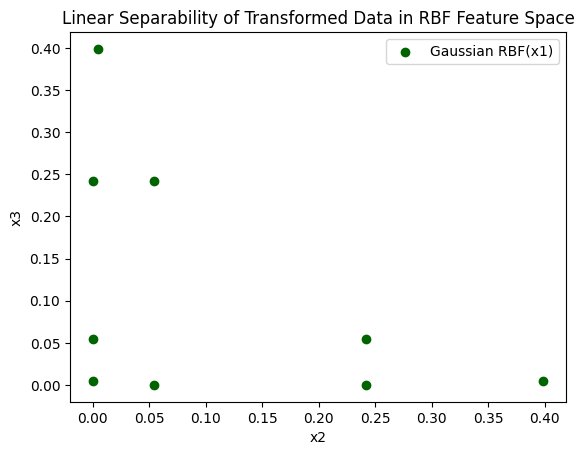

In [17]:
plt.scatter(x2, x3, c='DarkGreen', label='Gaussian RBF(x1)')
plt.legend()
plt.xlabel("x2"); plt.ylabel("x3")
plt.title('Linear Separability of Transformed Data in RBF Feature Space')

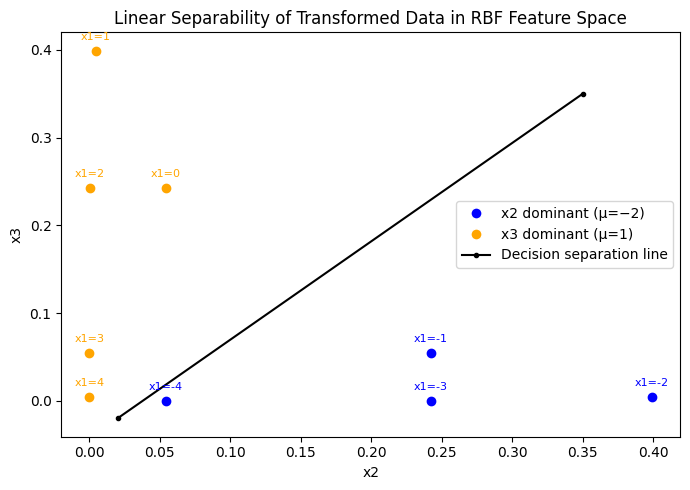

In [22]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a new figure and axes for this plot
fig, ax = plt.subplots(figsize=(7, 5))

# Iterate through data points to assign color based on dominance
for i, v in enumerate(x1):
    color = 'blue' if x2[i] >= x3[i] else 'orange' # Assign color based on which value is greater
    ax.scatter(x2[i], x3[i], c=color, zorder=3)
    ax.annotate(f'x1={v}', (x2[i], x3[i]), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8, color=color)

# Add a decision boundary line for visual clarity
ax.plot([0.02, 0.35], [-0.02, 0.35], 'k.-')

# Create a custom legend to explain the 'hue' (colors)
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='blue',   markersize=8, label='x2 dominant (μ=−2)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='x3 dominant (μ=1)'),
    Line2D([0],[0], color='k', linestyle='-', marker='.', label='Decision separation line'),
]
ax.legend(handles=legend_elements)

ax.set_xlabel('x2')
ax.set_ylabel('x3')
ax.set_title('Linear Separability of Transformed Data in RBF Feature Space')

plt.tight_layout()
plt.show()

In [13]:
data.round(2)

,x2,x3
x1,,
-4.0,0.05,0.00
-3.0,0.24,0.00
-2.0,0.40,0.00
-1.0,0.24,0.05
0.0,0.05,0.24
1.0,0.00,0.40
2.0,0.00,0.24
3.0,0.00,0.05
4.0,0.00,0.00


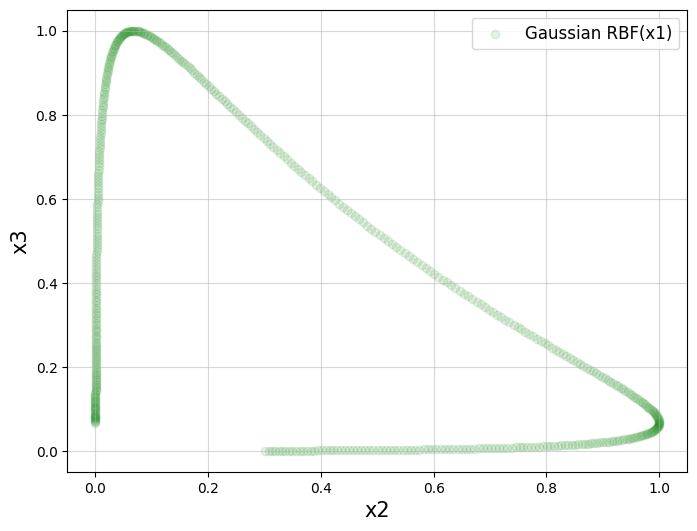

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 1차원 데이터 생성
x1 = np.linspace(-4, 4, 500)

# 2. RBF 커널 함수 정의 (기준점 landmarks: -2와 1)
def rbf_kernel(x, landmark, gamma=0.3):
    return np.exp(-gamma * (x - landmark)**2)

# 3. 새로운 차원(x2, x3)으로 변환
x2 = rbf_kernel(x1, landmark=-2)
x3 = rbf_kernel(x1, landmark=1)

# 4. 결과 시각화
plt.figure(figsize=(8, 6))
plt.scatter(x2, x3, color='green', alpha=0.1, label='Gaussian RBF(x1)')
# 간단한 결정 경계 예시 (x2 + x3 = 0.5)
# plt.plot([0, 0.35], [0.15, 0], color='red', label='Decision separation line')

plt.xlabel('x2', fontsize=15)
plt.ylabel('x3', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

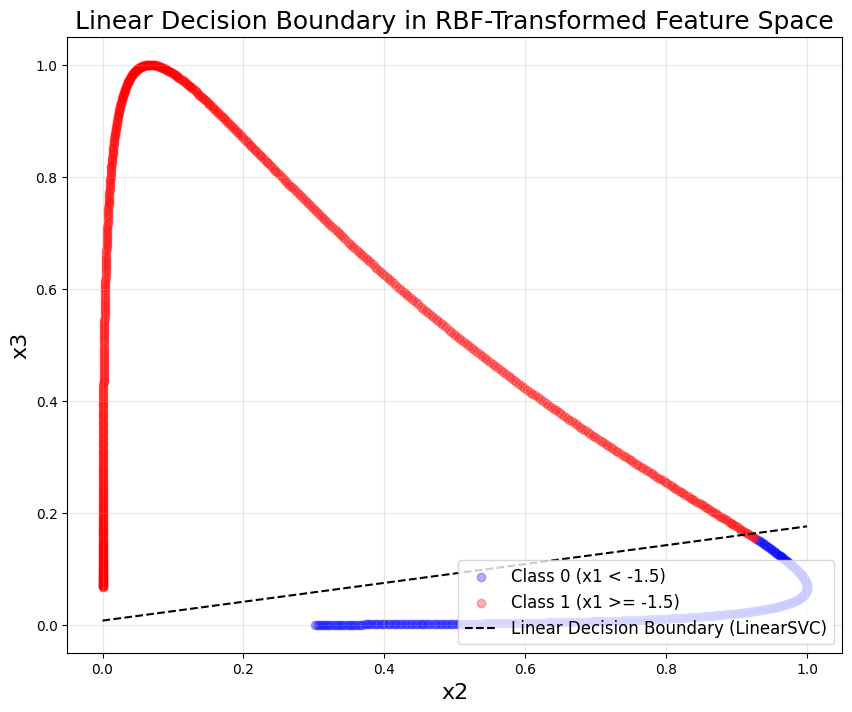

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC # 선형 분류기 학습을 위해 sklearn 사용

# 1. 1차원 데이터 생성 (1000개)
np.random.seed(42) # 결과 재현을 위해 시드 고정
x1 = np.linspace(-4, 4, 1000)

# 2. RBF 커널 함수 (landmark: -2, 1, gamma: 0.3)
def rbf_kernel(x, landmark, gamma=0.3):
    return np.exp(-gamma * (x - landmark)**2)

# 3. 2차원 특징 공간으로 변환 (x2, x3)
x2 = rbf_kernel(x1, landmark=-2)
x3 = rbf_kernel(x1, landmark=1)
X_transformed = np.c_[x2, x3]

# 4. 임의의 클래스 라벨(y) 생성 (가정)
# 예시: x1 < -1.5 이면 클래스 0, 아니면 클래스 1로 분류
y = np.where(x1 < -1.5, 0, 1)

# 5. 선형 SVM 모델 학습 (선형 결정 경계 찾기)
svm_clf = LinearSVC(C=10, loss="hinge", random_state=42, max_iter=10000)
svm_clf.fit(X_transformed, y)

# 6. 결과 시각화
plt.figure(figsize=(10, 8))

# 원본 데이터 시각화 (클래스별 색상 지정)
plt.scatter(x2[y==0], x3[y==0], color='blue', alpha=0.3, label='Class 0 (x1 < -1.5)')
plt.scatter(x2[y==1], x3[y==1], color='red', alpha=0.3, label='Class 1 (x1 >= -1.5)')

# 결정 경계선 그리기 (학습된 모델의 가중치(w)와 편향(b) 활용)
# w0*x2 + w1*x3 + b = 0 => x3 = -(w0*x2 + b) / w1
w = svm_clf.coef_[0]
b = svm_clf.intercept_[0]
x2_range = np.linspace(0, 1, 10)
x3_boundary = -(w[0] * x2_range + b) / w[1]
plt.plot(x2_range, x3_boundary, 'k--', label='Linear Decision Boundary (LinearSVC)')

# 그래프 스타일 설정
plt.xlabel("x2", fontsize=16)
plt.ylabel("x3", fontsize=16)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.title('Linear Decision Boundary in RBF-Transformed Feature Space', fontsize=18)
plt.show()